<!-- pip install openai rdflib spacy pyvis datasets scikit-learn matplotlib  nltk tqdm pandas -->

In [1]:
# Import necessary libraries
import os
import re
import json
from collections import Counter
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd
import time

# NLP and KG libraries
import spacy
from rdflib import Graph, Literal, Namespace, URIRef
from rdflib.namespace import RDF, RDFS, XSD, SKOS 

# OpenAI client for LLM
from openai import OpenAI

# Visualization
from pyvis.network import Network

# Hugging Face datasets library
from datasets import load_dataset

# For embedding similarity
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

/Users/linghuang/miniconda3/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cnn_dm_dataset=load_dataset("cnn_dailymail", "3.0.0")

Generating test split: 100%|██████████| 11490/11490 [00:00<00:00, 106412.58 examples/s]


In [5]:
total_records=len(cnn_dm_dataset["train"]) +len(cnn_dm_dataset["validation"]) +len(cnn_dm_dataset["test"])  # 打印总数和样本记录  
print(f"Total number of records in the dataset: {total_records}\n")
print("Sample record from the training dataset:")
print(cnn_dm_dataset["train"][0])

Total number of records in the dataset: 311971

Sample record from the training dataset:
{'article': 'LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won\'t cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don\'t think I\'ll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Ho

In [6]:
## Define Keywords

ACQUISITION_KEYWORDS= ["acquire", "acquisition", "merger", "buyout", "purchased by", "acquired by", "takeover"]   
TECH_KEYWORDS= ["technology", "software", "startup", "app", "platform", "digital", "AI", "cloud"]

In [13]:
cnn_dm_dataset_train = cnn_dm_dataset["train"]

filtered_articles = [
    record
    for record in cnn_dm_dataset_train
    if any(keyword.lower() in record["article"].lower() for keyword in ACQUISITION_KEYWORDS)
]

In [14]:
print(f"Total number of filtered articles: {len(filtered_articles)}")

Total number of filtered articles: 5589


In [16]:
filtered_articles = filtered_articles[:100]
print(f"Total number of filtered articles: {len(filtered_articles)}")

if filtered_articles:
    print("\nSample of a filtered article:")
    print(filtered_articles[0]["article"])
else:
    print("\nNo matching articles found.")

Total number of filtered articles: 100

Sample of a filtered article:
SAN DIEGO, California (CNN) -- You must know what's really driving the immigration debate. It's the culture, stupid. Ruben Navarrette Jr.: Some opponents of immigration, even the legal kind, fear changes in local culture. Immigration restrictionists -- and by that, I mean those who want to limit all immigration, even the legal kind -- like to pretend they're so high-minded. Yet they can't help themselves. They always take the low road and harken back to the nativism that greeted earlier waves of immigrants. The restrictionists insist that what bothers them are merely practical concerns: that our borders aren't secure, that so many immigrants are coming into the country illegally, and that the new arrivals are burdening schools and draining social services once they get here. Really? If that's the extent of it, then why does the conversation quickly turn to the impact -- both real and perceived -- that immigrants have

### Data Preparation

In [17]:
cleaned_articles = []

for record in filtered_articles:
    text = record["article"]

    # Basic cleanup with regex
    text = re.sub(r'^\(CNN\)\s*(--)?\s*', '', text)
    text = re.sub(r'By .*? for Dailymail\.com.*?Updated:.*', '', text, flags=re.I | re.S)
    text = re.sub(r'PUBLISHED:.*?UPDATED:.*', '', text, flags=re.I | re.S)
    text = re.sub(r'Last updated at.*on.*', '', text, flags=re.I)
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\b[\w.-]+@[\w.-]+\.\w+\b', '[EMAIL]', text)
    text = re.sub(r'\s+', ' ', text).strip()

    cleaned_articles.append({
        "id": record["id"],
        "cleaned_text": text,
        "summary": record.get("highlights", "")
    })


### Step 1

In [18]:
import spacy
from spacy.util import is_package
from collections import Counter

if not is_package("en_core_web_sm"):
    spacy.cli.download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")

entity_counts = Counter()

for article in cleaned_articles:
    doc = nlp(article["cleaned_text"])
    for ent in doc.ents:
        entity_counts[ent.label_] += 1

In [19]:
print(entity_counts.most_common(10))

[('ORG', 1774), ('PERSON', 1483), ('GPE', 1376), ('DATE', 1063), ('NORP', 617), ('CARDINAL', 478), ('MONEY', 164), ('LOC', 162), ('ORDINAL', 113), ('TIME', 79)]


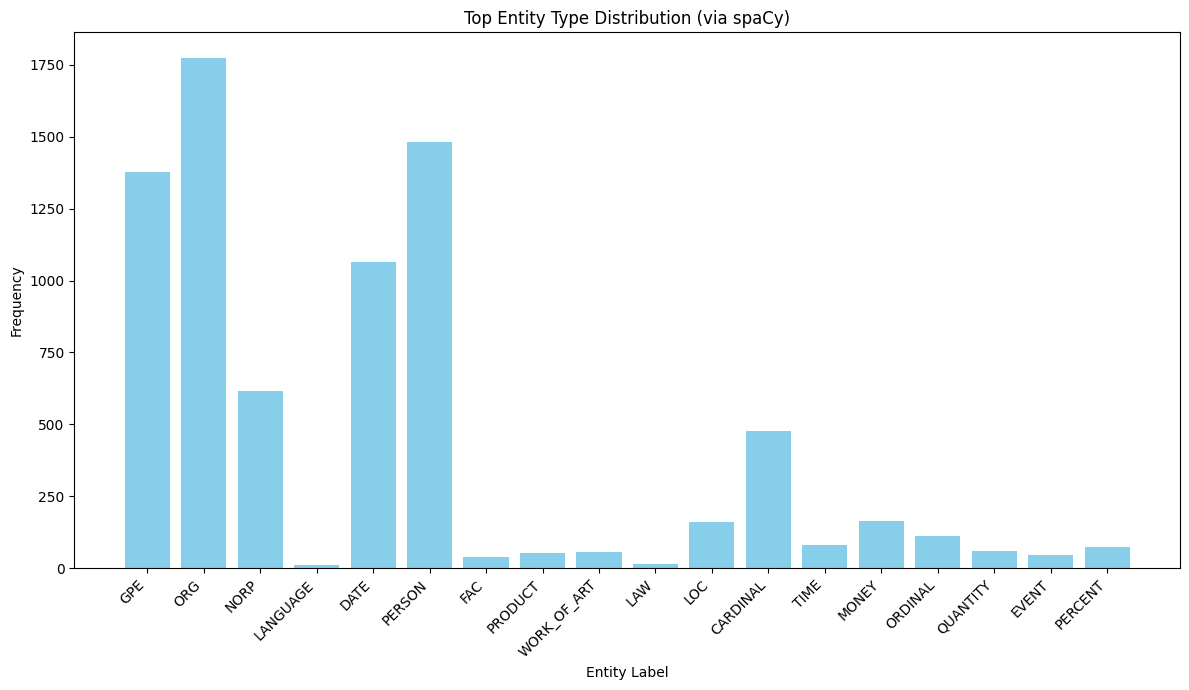

In [20]:
# Extract labels and counts
labels, counts = zip(*entity_counts.items())

# Plot bar chart
plt.figure(figsize=(12, 7))
plt.bar(labels, counts, color="skyblue")
plt.title("Top Entity Type Distribution (via spaCy)")
plt.ylabel("Frequency")
plt.xlabel("Entity Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Extract Entity

In [32]:
import os
import nltk

NLTK_DATA_DIR = os.path.expanduser("~/nltk_data")
os.makedirs(NLTK_DATA_DIR, exist_ok=True)

if NLTK_DATA_DIR not in nltk.data.path:
    nltk.data.path.append(NLTK_DATA_DIR)

packages = [
    "punkt",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "maxent_ne_chunker",
    "maxent_ne_chunker_tab",
    "words",
]

for pkg in packages:
    nltk.download(pkg, download_dir=NLTK_DATA_DIR)

print("NLTK paths:")
for p in nltk.data.path:
    print("-", p)

[nltk_data] Downloading package punkt to /Users/linghuang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/linghuang/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/linghuang/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/linghuang/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /Users/linghuang/nltk_data...


NLTK paths:
- /Users/linghuang/nltk_data
- /Users/linghuang/miniconda3/envs/llm/nltk_data
- /Users/linghuang/miniconda3/envs/llm/share/nltk_data
- /Users/linghuang/miniconda3/envs/llm/lib/nltk_data
- /usr/share/nltk_data
- /usr/local/share/nltk_data
- /usr/lib/nltk_data
- /usr/local/lib/nltk_data


[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /Users/linghuang/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [35]:
def run_nltk_ner(text, allowed_entity_types=None):
    """
    NLTK-based NER with output aligned to a simple JSON format.

    Args:
        text (str): Input text
        allowed_entity_types (list[str] | None): e.g. ["PERSON", "ORG", "GPE"]

    Returns:
        dict: {"entities": [{"text": "...", "type": "..."}]}
    """
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    tree = nltk.ne_chunk(pos_tags)

    label_map = {
        "PERSON": "PERSON",
        "ORGANIZATION": "ORG",
        "GPE": "GPE",
        "LOCATION": "LOC",
        "FACILITY": "FAC",
    }

    entities = []

    for subtree in tree:
        if hasattr(subtree, "label"):
            entity_type = subtree.label()
            mapped_type = label_map.get(entity_type, entity_type)
            entity_text = " ".join(token for token, _ in subtree)

            if allowed_entity_types is None or mapped_type in allowed_entity_types:
                entities.append({
                    "text": entity_text,
                    "type": mapped_type,
                })

    return {"entities": entities}

In [36]:
article_text = cleaned_articles[0]["cleaned_text"]
relevant_entity_labels_for_llm = ["PERSON", "ORG", "GPE", "LOC", "FAC"]

result = run_nltk_ner(
    text=article_text,
    allowed_entity_types=relevant_entity_labels_for_llm
)

print(json.dumps(result, ensure_ascii=False, indent=2))

{
  "entities": [
    {
      "text": "SAN",
      "type": "ORG"
    },
    {
      "text": "DIEGO",
      "type": "GPE"
    },
    {
      "text": "California",
      "type": "GPE"
    },
    {
      "text": "CNN",
      "type": "ORG"
    },
    {
      "text": "Ruben Navarrette",
      "type": "PERSON"
    },
    {
      "text": "American",
      "type": "GPE"
    },
    {
      "text": "North Dakota",
      "type": "GPE"
    },
    {
      "text": "USA",
      "type": "ORG"
    },
    {
      "text": "Cooperstown",
      "type": "GPE"
    },
    {
      "text": "American",
      "type": "GPE"
    },
    {
      "text": "Starbucks",
      "type": "FAC"
    },
    {
      "text": "Orville Tranby",
      "type": "PERSON"
    },
    {
      "text": "Cooperstown",
      "type": "GPE"
    },
    {
      "text": "Lewisburg",
      "type": "GPE"
    },
    {
      "text": "Tennessee",
      "type": "GPE"
    },
    {
      "text": "Spanish",
      "type": "GPE"
    },
    {
      "text": "T

In [38]:
articles_with_llm_entities = []

for i, article_data in enumerate(cleaned_articles):
    article_id = article_data["id"]
    article_text = article_data["cleaned_text"]

    nltk_result = run_nltk_ner(
        text=article_text,
        allowed_entity_types=relevant_entity_labels_for_llm
    )

    extracted_entities = nltk_result["entities"]

    articles_with_llm_entities.append({
        "id": article_id,
        "cleaned_text": article_text,
        "summary": article_data["summary"],
        "llm_extracted_entities": extracted_entities, ## use nltk to replace it
    })

In [39]:
print(articles_with_llm_entities[12]['llm_extracted_entities'])  

[{'text': 'NEW YORK', 'type': 'GPE'}, {'text': 'CNN', 'type': 'ORG'}, {'text': 'Russian', 'type': 'GPE'}, {'text': 'Viktor Bout', 'type': 'PERSON'}, {'text': 'Bout', 'type': 'PERSON'}, {'text': 'Andrew Smulian', 'type': 'PERSON'}, {'text': 'Thailand', 'type': 'GPE'}, {'text': 'U.S.', 'type': 'GPE'}, {'text': 'Colombian', 'type': 'GPE'}, {'text': 'Bout', 'type': 'PERSON'}, {'text': 'Smulian', 'type': 'GPE'}, {'text': 'Colombian', 'type': 'GPE'}, {'text': 'Michael Garcia', 'type': 'PERSON'}, {'text': 'U.S.', 'type': 'GPE'}, {'text': 'Southern District', 'type': 'LOC'}, {'text': 'New York', 'type': 'GPE'}, {'text': 'DEA', 'type': 'ORG'}, {'text': 'Colombia', 'type': 'GPE'}, {'text': 'FARC', 'type': 'ORG'}, {'text': 'U.S. Department', 'type': 'ORG'}, {'text': 'State', 'type': 'ORG'}, {'text': 'Garcia', 'type': 'PERSON'}, {'text': 'Bout', 'type': 'GPE'}, {'text': 'Tom Clancy', 'type': 'PERSON'}, {'text': 'Michael Braun', 'type': 'PERSON'}, {'text': 'DEA', 'type': 'ORG'}, {'text': 'Smulian',

### Extract Edges

In [40]:
import nltk
import re

# Run once if needed
# nltk.download("punkt")

ACQUISITION_PATTERNS = [
    r"{subj}\s+(?:has\s+)?(?:acquired|bought|purchased|took over)\s+{obj}",
    r"{subj}\s+(?:announced\s+)?(?:its\s+)?acquisition of\s+{obj}",
    r"{subj}\s+(?:completed|closed|finalized)\s+(?:the\s+)?acquisition of\s+{obj}",
    r"{obj}\s+was\s+acquired\s+by\s+{subj}",
    r"{obj}\s+was\s+bought\s+by\s+{subj}",
]


def normalize_entity_text(text):
    return re.escape(text.strip())


def extract_acquisition_relationships(text, entities):
    """
    Rule-based relation extraction for acquisition events.

    Args:
        text (str): Article text
        entities (list[dict]): 
            [
                {"text": "Microsoft", "type": "ORG"},
                {"text": "LinkedIn", "type": "ORG"}
            ]

    Returns:
        dict: {"relationships": [...]}
    """

    relationships = []
    seen = set()

    # Usually acquisitions are ORG -> ORG
    org_entities = [
        e for e in entities
        if e.get("type") in {"ORG", "ORGANIZATION"}
    ]

    sentences = nltk.sent_tokenize(text)

    for sent in sentences:
        sent_lower = sent.lower()

        for subj in org_entities:
            for obj in org_entities:
                if subj["text"] == obj["text"]:
                    continue

                subj_text = subj["text"]
                obj_text = obj["text"]

                subj_pattern = normalize_entity_text(subj_text)
                obj_pattern = normalize_entity_text(obj_text)

                for pattern in ACQUISITION_PATTERNS:
                    regex = pattern.format(
                        subj=subj_pattern,
                        obj=obj_pattern
                    )

                    if re.search(regex, sent, flags=re.IGNORECASE):
                        rel = {
                            "subject_text": subj_text,
                            "subject_type": subj["type"],
                            "predicate": "ACQUIRED",
                            "object_text": obj_text,
                            "object_type": obj["type"]
                        }

                        key = (
                            rel["subject_text"].lower(),
                            rel["predicate"],
                            rel["object_text"].lower()
                        )

                        if key not in seen:
                            seen.add(key)
                            relationships.append(rel)

    return {"relationships": relationships}

In [41]:
articles_with_llm_relations = []

for article_entity_data in articles_with_llm_entities:
    article_text = article_entity_data["cleaned_text"]
    current_entities = article_entity_data["llm_extracted_entities"]

    rel_result = extract_acquisition_relationships(
        text=article_text,
        entities=current_entities
    )

    articles_with_llm_relations.append({
        **article_entity_data,
        "llm_extracted_relationships": rel_result["relationships"]
    })

### Entity Normalization

In [44]:
import re
import hashlib
from tqdm.auto import tqdm
from rdflib import Graph, Literal, Namespace, URIRef
from rdflib.namespace import RDF, RDFS, XSD, SKOS

SCHEMA = Namespace("http://schema.org/")
EX = Namespace("http://example.org/kg/")

In [45]:
def normalize_entity_text_for_uri(entity_text, entity_type):
    """
    Normalize entity text, mainly by stripping common organization suffixes.
    """
    normalized_text = entity_text.strip()

    if entity_type == "ORG":
        suffixes_to_remove = [
            "Inc.", "Incorporated", "Ltd.", "Limited", "LLC", "L.L.C.",
            "Corp.", "Corporation", "PLC", "Co.", "Company",
            "Group", "Holdings", "Solutions", "Technologies", "Systems"
        ]
        suffixes_to_remove.sort(key=len, reverse=True)

        for suffix in suffixes_to_remove:
            if (
                normalized_text.lower().endswith(" " + suffix.lower())
                or normalized_text.lower() == suffix.lower()
            ):
                suffix_start_index = normalized_text.lower().rfind(suffix.lower())
                normalized_text = normalized_text[:suffix_start_index].strip()
                break

        normalized_text = re.sub(r"[,.]*$", "", normalized_text).strip()

    if normalized_text.endswith("'s") or normalized_text.endswith("s'"):
        normalized_text = normalized_text[:-2].strip()

    return normalized_text if normalized_text else entity_text

In [47]:
articles_with_normalized_entities_and_uris = []
unique_entities_map = {}

print("KG Namespace EX defined.")

for article in tqdm(articles_with_llm_relations, desc="Normalizing & URI Gen"):
    processed = []

    for ent in article.get("llm_extracted_entities", []):
        text = ent["text"]
        type_raw = ent["type"]
        type_simple = type_raw.split()[0].upper()

        norm_text = normalize_entity_text_for_uri(text, type_simple)
        key = (norm_text, type_simple)

        if key not in unique_entities_map:
            safe_text = re.sub(r"[^a-zA-Z0-9_]", "_", norm_text.replace(" ", "_"))[:50]
            if not safe_text:
                safe_text = f"entity_{hashlib.md5(norm_text.encode()).hexdigest()[:8]}"
            unique_entities_map[key] = EX[f"{safe_text}_{type_simple}"]

        processed.append({
            **ent,
            "normalized_text": norm_text,
            "simple_type": type_simple,
            "uri": unique_entities_map[key],
        })

    articles_with_normalized_entities_and_uris.append({
        **article,
        "processed_entities": processed,
    })


KG Namespace EX defined.


Normalizing & URI Gen: 100%|██████████| 100/100 [00:00<00:00, 394.85it/s]


In [48]:
print("Example of processed entities from one article:")
for ent in articles_with_normalized_entities_and_uris[0]["processed_entities"][:3]:
    print(f"  Original: '{ent['text']}' ({ent['type']})")
    print(f"  Normalized: '{ent['normalized_text']}' (Simple Type: {ent['simple_type']})")
    print(f"  URI: <{ent['uri']}>")


Example of processed entities from one article:
  Original: 'SAN' (ORG)
  Normalized: 'SAN' (Simple Type: ORG)
  URI: <http://example.org/kg/SAN_ORG>
  Original: 'DIEGO' (GPE)
  Normalized: 'DIEGO' (Simple Type: GPE)
  URI: <http://example.org/kg/DIEGO_GPE>
  Original: 'California' (GPE)
  Normalized: 'California' (Simple Type: GPE)
  URI: <http://example.org/kg/California_GPE>


### RDF Class

In [49]:
def get_rdf_class_for_entity_type(simple_entity_type_str):
    """
    Map a simple entity type string like ORG to an RDF class URI.
    """
    type_to_rdf_class_map = {
        "ORG": SCHEMA.Organization,
        "PERSON": SCHEMA.Person,
        "MONEY": SCHEMA.PriceSpecification,
        "DATE": SCHEMA.Date,
        "PRODUCT": SCHEMA.Product,
        "GPE": SCHEMA.Place,
        "LOC": SCHEMA.Place,
        "EVENT": SCHEMA.Event,
        "NORP": EX.NORP,
        "CARDINAL": XSD.integer,
    }
    return type_to_rdf_class_map.get(
        simple_entity_type_str.upper(),
        EX[simple_entity_type_str.upper()]
    )

In [ ]:
print("Example RDF Class mappings for our entity types:")

sample_type1 = 'ORG'
rdf_class1 = get_rdf_class_for_entity_type(sample_type1)
print(f"  Entity Type '{sample_type1}' maps to RDF Class: <{rdf_class1}>")

sample_type2 = 'MONEY'
rdf_class2 = get_rdf_class_for_entity_type(sample_type2)
print(f"  Entity Type '{sample_type2}' maps to RDF Class: <{rdf_class2}>")

sample_type3 = 'INVESTMENT_ROUND'
rdf_class3 = get_rdf_class_for_entity_type(sample_type3)
print(f"  Entity Type '{sample_type3}' (custom) maps to RDF Class: <{rdf_class3}>")

Example RDF Class mappings for our entity types:
  Entity Type 'ORG' maps to RDF Class: <http://schema.org/Organization>
  Entity Type 'MONEY' maps to RDF Class: <http://schema.org/PriceSpecification>
  Entity Type 'INVESTMENT_ROUND' (custom) maps to RDF Class: <http://example.org/kg/INVESTMENT_ROUND>


### RDF Prediction

In [50]:
def get_rdf_predicate_uri(predicate_string_from_llm):
    sanitized_predicate = predicate_string_from_llm.strip().replace(" ", "_").upper()
    return EX[sanitized_predicate]


In [51]:
kg = Graph()
kg.bind("ex", EX)
kg.bind("schema", SCHEMA)
kg.bind("rdfs", RDFS)
kg.bind("skos", SKOS)

total_triples_added = 0

for article in tqdm(articles_with_normalized_entities_and_uris):
    article_uri = EX[f"article_{str(article['id']).replace('-', '_')}"]
    kg.add((article_uri, RDF.type, SCHEMA.Article))

    label = article.get("summary") or f"Article {article['id']}"
    pred = SCHEMA.headline if article.get("summary") else RDFS.label
    kg.add((article_uri, pred, Literal(label, lang="en")))
    total_triples_added += 2

    entity_map = {}

    for e in article.get("processed_entities", []):
        uri = e["uri"]
        kg.add((uri, RDF.type, get_rdf_class_for_entity_type(e["simple_type"])))
        kg.add((uri, RDFS.label, Literal(e["normalized_text"], lang="en")))
        if e["text"] != e["normalized_text"]:
            kg.add((uri, SKOS.altLabel, Literal(e["text"], lang="en")))
        kg.add((article_uri, SCHEMA.mentions, uri))
        total_triples_added += 4
        entity_map[e["text"]] = uri

    for r in article.get("llm_extracted_relationships", []):
        s_uri = entity_map.get(r.get("subject_text"))
        o_uri = entity_map.get(r.get("object_text"))
        predicate = r.get("predicate")
        if s_uri and o_uri and predicate:
            p_uri = get_rdf_predicate_uri(predicate)
            kg.add((s_uri, p_uri, o_uri))
            total_triples_added += 1


100%|██████████| 100/100 [00:01<00:00, 50.71it/s]


### Save Knowledge Graph

In [52]:
def save_knowledge_graph_to_file(graph_object, output_filepath="my_knowledge_graph.ttl", rdf_format="turtle"):
    if not graph_object or len(graph_object) == 0:
        print("Knowledge graph is empty. Nothing to save.")
        return False

    try:
        graph_object.serialize(destination=output_filepath, format=rdf_format)
        print(f"Saved knowledge graph with {len(graph_object)} triples to: {output_filepath}")
        return True
    except Exception as e:
        print(f"Error saving knowledge graph to {output_filepath}: {e}")
        return False

In [53]:
def execute_and_print_sparql_query(graph, query, title="SPARQL Query"):
    print(f"\n--- {title} ---\nQuery:\n{query}")
    results = graph.query(query)
    results_list = [{str(var): str(val) for var, val in row.asdict().items()} for row in results]

    print(f"\nResults ({len(results_list)} found):")
    for i, result in enumerate(results_list[:10]):
        print(f"  {i+1}: {result}")
    if len(results_list) > 10:
        print(f"  ... (and {len(results_list) - 10} more results)")

    return results_list


In [55]:
def visualize_kg(graph, filename="kg_viz.html", num_triples=50):
    net = Network(height="600px", width="100%", directed=True)

    triples = [
        (s, p, o)
        for s, p, o in graph
        if isinstance(s, URIRef) and isinstance(o, URIRef)
    ][:num_triples]

    nodes = set()

    for s, p, o in tqdm(triples, desc="Visualizing"):
        for node in (s, o):
            if node not in nodes:
                label = graph.value(node, RDFS.label) or node.n3(graph.namespace_manager)
                if isinstance(label, Literal):
                    label = str(label)
                ntype = graph.value(node, RDF.type)
                group = ntype.n3(graph.namespace_manager).split(":")[-1] if ntype else "Unknown"
                net.add_node(str(node), label=label, group=group, title=str(node))
                nodes.add(node)

        pred_label = p.n3(graph.namespace_manager).split(":")[-1]
        net.add_edge(str(s), str(o), label=pred_label, title=pred_label, arrows="to")

    net.save_graph(filename)
    print(f"Visualization saved to {filename}")
    return net

### KG Analysis

In [56]:
KG_FILENAME = "tech_acquisitions_knowledge_graph.ttl"
save_knowledge_graph_to_file(kg, output_filepath=KG_FILENAME, rdf_format="turtle")

sample_query = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>

SELECT DISTINCT ?org_label ?org_uri
WHERE {
    ?org_uri rdf:type schema:Organization .
    ?org_uri rdfs:label ?org_label .
}
ORDER BY ?org_label
LIMIT 10
"""

Saved knowledge graph with 7893 triples to: tech_acquisitions_knowledge_graph.ttl


In [57]:
org_results = execute_and_print_sparql_query(kg, sample_query, "Organizations In KG")

kg_visualization_net = visualize_kg(
    kg,
    filename="tech_acquisitions_kg_visualization.html",
    num_triples=75
)


--- Organizations In KG ---
Query:

PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema: <http://schema.org/>

SELECT DISTINCT ?org_label ?org_uri
WHERE {
    ?org_uri rdf:type schema:Organization .
    ?org_uri rdfs:label ?org_label .
}
ORDER BY ?org_label
LIMIT 10


Results (10 found):
  1: {'org_label': 'AC Milan', 'org_uri': 'http://example.org/kg/AC_Milan_ORG'}
  2: {'org_label': 'ADL', 'org_uri': 'http://example.org/kg/ADL_ORG'}
  3: {'org_label': 'AIG', 'org_uri': 'http://example.org/kg/AIG_ORG'}
  4: {'org_label': 'AIG Corp', 'org_uri': 'http://example.org/kg/AIG_Corp_ORG'}
  5: {'org_label': 'ALGIERS', 'org_uri': 'http://example.org/kg/ALGIERS_ORG'}
  6: {'org_label': 'AOL', 'org_uri': 'http://example.org/kg/AOL_ORG'}
  7: {'org_label': 'AOL Autos', 'org_uri': 'http://example.org/kg/AOL_Autos_ORG'}
  8: {'org_label': 'APO', 'org_uri': 'http://example.org/kg/APO_ORG'}
  9: {'org_label': 'ASAP', 'org_uri':

Visualizing: 100%|██████████| 75/75 [00:00<00:00, 4668.85it/s]

Visualization saved to tech_acquisitions_kg_visualization.html
